# Ecommerce Revenue Analytics
This notebook imports custom python modules from `scripts/` to clean data, engineer new features, and perform KPI analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Add scripts directory to Python path
sys.path.append('../scripts')
import data_cleaning as dc
import feature_engineering as fe
import kpi_analysis as kpi

# Setting aesthetic style for plots
sns.set_theme(style="whitegrid")

In [2]:
# Load Raw Data
data_dir = '../data'
customers = pd.read_csv(f'{data_dir}/customers.csv')
orders = pd.read_csv(f'{data_dir}/orders.csv')
order_items = pd.read_csv(f'{data_dir}/order_items.csv')
refunds = pd.read_csv(f'{data_dir}/refunds.csv')
traffic = pd.read_csv(f'{data_dir}/traffic.csv')

print("Raw data loaded successfully.")

Raw data loaded successfully.


In [3]:
# 1. Apply Data Cleaning Methods
customers_clean = dc.clean_customers(customers)
orders_clean = dc.clean_orders(orders)
order_items_clean = dc.clean_order_items(order_items)
refunds_clean = dc.clean_refunds(refunds)
traffic_clean = dc.clean_traffic(traffic)

print(f"Cleaned orders dataset shape: {orders_clean.shape}")

Cleaned orders dataset shape: (5000, 4)


D:\Data_Analyst\E-Commerce Revenue & Customer Intelligence System\Scripts\Ecommerce-Revenue-Analytics\notebooks\../scripts\data_cleaning.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=True)


In [4]:
# 2. Feature Engineering
merged_df, clv = fe.apply_feature_engineering(orders_clean, order_items_clean)

print("Feature engineering complete. Merged DataFrame shape:", merged_df.shape)
merged_df.head()

Feature engineering complete. Merged DataFrame shape: (12000, 13)


,order_item_id,order_id,product_id,category,price,quantity,revenue,customer_id,order_date,status,order_year,order_month,order_year_month
0,1,3783,184,Clothing,370.41,3,1111.23,726,2023-12-25,Completed,2023,12,2023-12
1,2,1363,394,Home & Garden,445.33,1,445.33,173,2023-06-04,Processing,2023,6,2023-06
2,3,4282,494,Toys,387.19,3,1161.57,362,2023-04-24,Completed,2023,4,2023-04
3,4,2635,135,Clothing,150.50,4,602.00,540,2023-12-17,Completed,2023,12,2023-12
4,5,1525,117,Sports,296.10,1,296.10,232,2023-12-14,Completed,2023,12,2023-12


In [5]:
# 3. KPI Analysis
total_rev = kpi.calculate_total_revenue(merged_df)
aov = kpi.calculate_aov(merged_df)
conv_rate = kpi.calculate_conversion_rate(orders_clean, traffic_clean)
refund_rate = kpi.calculate_refund_rate(orders_clean, refunds_clean)

print(f"--- KEY METRICS ---")
print(f"Total Revenue: ${total_rev:,.2f}")
print(f"Average Order Value: ${aov:,.2f}")
print(f"Conversion Rate: {conv_rate:.2f}%")
print(f"Refund Rate: {refund_rate:.2f}%")

--- KEY METRICS ---
Total Revenue: $6,568,595.46
Average Order Value: $1,711.46
Conversion Rate: 0.46%
Refund Rate: 7.06%


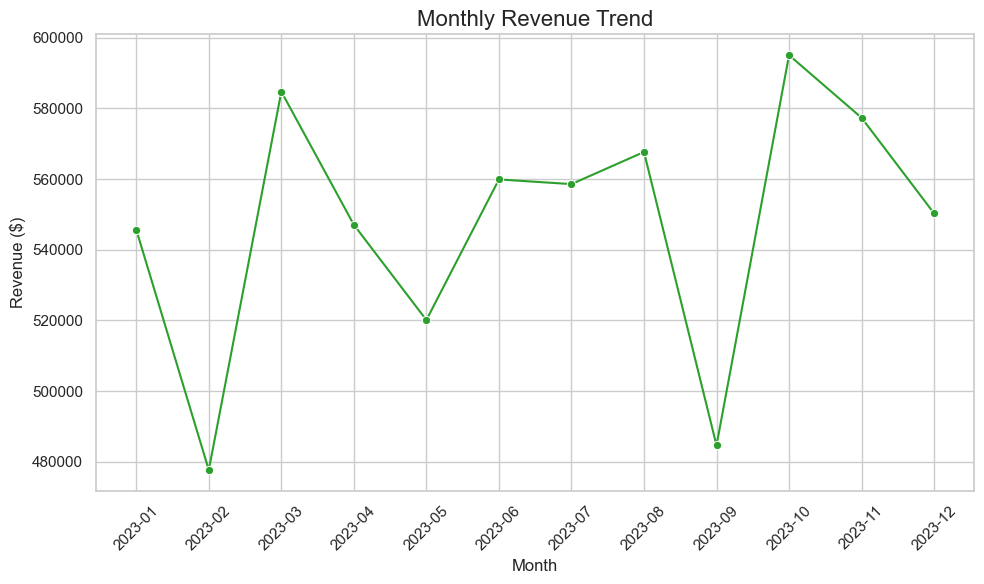

In [6]:
# 4. Data Visualization
visuals_dir = '../visuals'
os.makedirs(visuals_dir, exist_ok=True)

# 4.1 Monthly Revenue Trend
monthly_revenue = merged_df[merged_df['status'] == 'Completed'].groupby('order_year_month', observed=True)['revenue'].sum().reset_index()
monthly_revenue['order_year_month'] = monthly_revenue['order_year_month'].astype(str)

plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_revenue, x='order_year_month', y='revenue', marker='o', color='#2ca02c')
plt.title('Monthly Revenue Trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{visuals_dir}/revenue_trend.png')
plt.show()

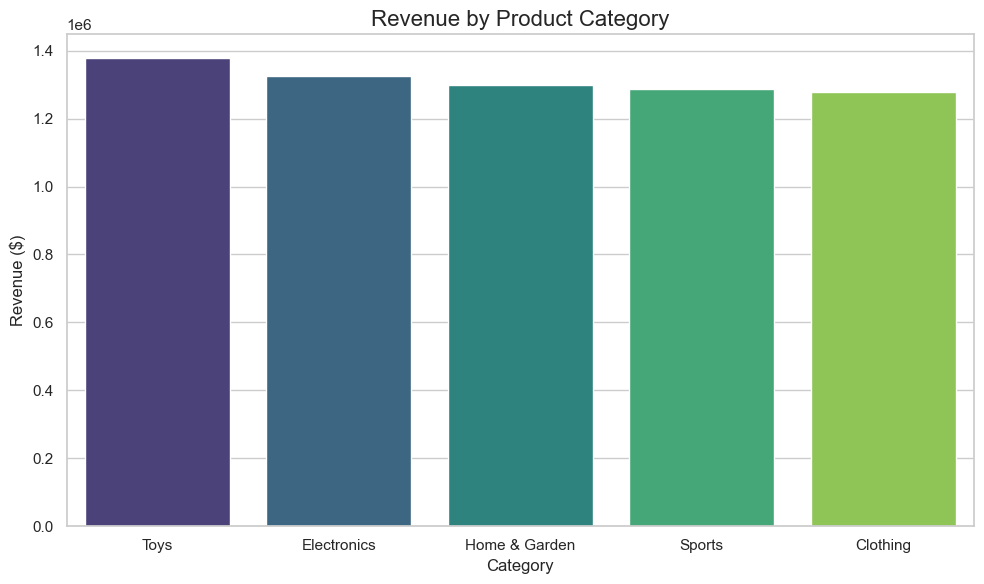

In [7]:
# 4.2 Revenue by Category
cat_revenue = kpi.get_revenue_by_category(merged_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=cat_revenue, x='category', y='revenue', palette='viridis', hue='category', legend=False)
plt.title('Revenue by Product Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{visuals_dir}/category_revenue.png')
plt.show()

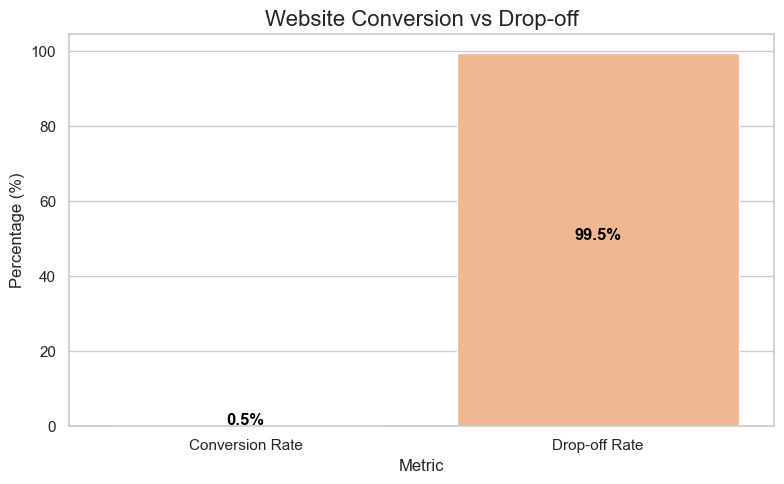

In [8]:
# 4.3 Website Conversion Rate
conv_data = pd.DataFrame({
    'Metric': ['Conversion Rate', 'Drop-off Rate'],
    'Percentage': [conv_rate, 100 - conv_rate]
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=conv_data, x='Metric', y='Percentage', palette='pastel', hue='Metric', legend=False)
plt.title('Website Conversion vs Drop-off', fontsize=16)
plt.ylabel('Percentage (%)', fontsize=12)

for index, row in conv_data.iterrows():
    ax.text(index, row.Percentage / 2, f"{row.Percentage:.1f}%", color='black', ha="center", fontsize=12, weight='bold')

plt.tight_layout()
plt.savefig(f'{visuals_dir}/conversion_rate.png')
plt.show()